
# Detailed Blockchain Lab Notebook with Visualizations
This notebook provides:
- Clear explanations for each concept
- A full blockchain implementation
- Proof-of-Work, difficulty, transactions, mining rewards
- Mining time visualization
---


**Note:
A real blockchain is a distributed system with multiple nodes, networks, consensus rules, and security mechanisms.
This notebook provides only a simplified, single‑node demonstration for learning purposes.**

##  Imports

In [8]:
import hashlib  # for SHA‑256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints

**Block Class**

A block contains transactions and must be mined by finding a valid hash starting with a number of leading zeros determined by the difficulty.

In [10]:

class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.transactions = transactions # list of txs
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()  # compute hash

    def mine(self):
        target = '0' * self.difficulty  # target prefix
        start = time.time()             # start time
        attempts = 0                    # count tries
        while True:
            self.hash = self.compute_hash()  # calculate hash
            if self.hash.startswith(target):  # valid PoW?
                break
            self.nonce += 1                  # try next nonce
            attempts += 1
        return time.time() - start, attempts  # mining duration + attempts


##  Blockchain Class

The blockchain links blocks together and manages transactions, mining, verification, and exporting.

In [12]:

class Blockchain:
    def __init__(self, difficulty=3, reward=10):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty
        )
        b.mine()                       # mine genesis block
        self.chain.append(b)           # add to chain

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })                             # store pending tx

    def mine_pending(self, miner):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending            # include reward + pending txs
        prev = self.chain[-1]                       # last block
        b = Block(len(self.chain), time.time(), txs, prev.hash, self.difficulty)
        t, attempts = b.mine()                      # mine new block
        self.chain.append(b)                        # add block to chain
        self.pending = []                           # clear mempool
        return t, attempts                          # return mining stats

    def export_json(self, filename):
        data = [b.__dict__ for b in self.chain]     # serialize blocks
        s = json.dumps(data, indent=2)              # format JSON
        open(filename, 'w').write(s)                # write file
        return s                                    # return JSON string


## 🚀 Example: Create Blockchain and Add Transactions

In [14]:

bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 13.597737789154053 seconds
Attempts: 1647392


In [15]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")
    print(f" Transactions: {b.transactions}")
    print("-" * 50)

Block #0
 Timestamp   : 1775219194.1809385
 Hash        : 0000029309be85022572e82203bd6e735f9fd9f2e6ad3af35f34422291d2dba7
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 591
 Transactions: [{'sender': 'network', 'recipient': 'genesis', 'amount': 0}]
--------------------------------------------------
Block #1
 Timestamp   : 1775219194.1840408
 Hash        : 00000026b23ac4437d73cb9c15d6b3c7ddb3cea2006fc3ce6c3acace77bbef38
 Prev Hash   : 0000029309be85022572e82203bd6e735f9fd9f2e6ad3af35f34422291d2dba7
 Difficulty  : 5
 Nonce       : 1647392
 Transactions: [{'sender': 'network', 'recipient': 'Miner1', 'amount': 25}, {'sender': 'Alice', 'recipient': 'Bob', 'amount': 10}, {'sender': 'Bob', 'recipient': 'Charlie', 'amount': 5}, {'sender': 'Charlie', 'recipient': 'Dave', 'amount': 2}]
--------------------------------------------------


## Mining Time Visualization

We test multiple difficulty levels and plot the mining times to show how difficulty impacts mining cost.

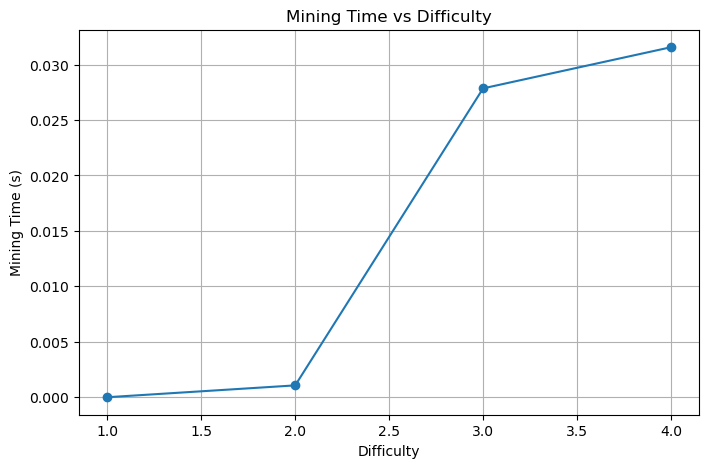

In [16]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    bc = Blockchain(difficulty=d, reward=1)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


#  Student Challenges
1. Note that your data is not encrypted inside the blocks, so anyone can read it. Encrypt the data before storing it in each block. Use encryption methods such as AES or 3DES.

2. Modify the mining function so it no longer uses leading‑zero matching; instead apply a different Proof‑of‑Work rule, such as a numeric hash threshold, pattern matching, or a time‑limited mining attempt.

Some options can be:

* Numeric threshold: Convert the hash to an integer and check if it's below a target value.
* Pattern rule: Make the hash end with certain characters (e.g., "00"), or require a substring inside the hash.
* Time‑limited PoW: Stop mining after a fixed time or attempt limit and mark the block as failed.
* Difficulty idea: Control difficulty by adjusting pattern length or the numeric target size.


# LAB-LOGBOOK requirement:
Show a graph comparing the mining time of the different Proof‑of‑Work methods used in Challenge 2.









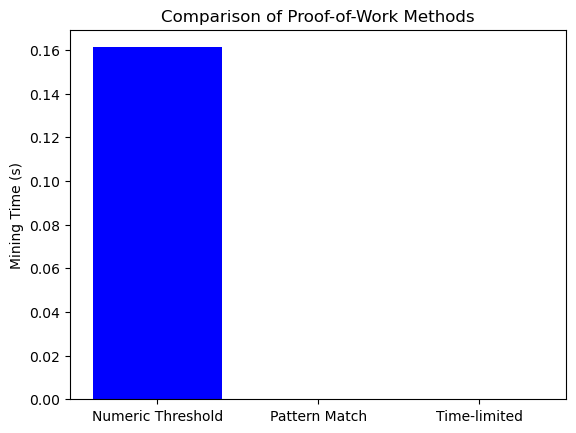

In [23]:
import hashlib
import time
from cryptography.fernet import Fernet
import matplotlib.pyplot as plt

# -----------------------------
# 1. AES Encryption Setup
# -----------------------------
key = Fernet.generate_key()
cipher = Fernet(key)

def encrypt_data(data):
    return cipher.encrypt(data.encode())

# Example block data
data = "Alice pays Bob 10 coins"
encrypted_data = encrypt_data(data)

# -----------------------------
# 2. Proof-of-Work Methods
# -----------------------------
def mine_numeric_threshold(encrypted_data, target=2**240):
    nonce = 0
    start_time = time.time()
    while True:
        text = f"{encrypted_data}{nonce}".encode()
        hash_result = hashlib.sha256(text).hexdigest()
        if int(hash_result, 16) < target:
            return time.time() - start_time
        nonce += 1

def mine_pattern(encrypted_data, pattern="00"):
    nonce = 0
    start_time = time.time()
    while True:
        text = f"{encrypted_data}{nonce}".encode()
        hash_result = hashlib.sha256(text).hexdigest()
        if hash_result.endswith(pattern):
            return time.time() - start_time
        nonce += 1

def mine_time_limited(encrypted_data, pattern="00", time_limit=5):
    nonce = 0
    start_time = time.time()
    while True:
        text = f"{encrypted_data}{nonce}".encode()
        hash_result = hashlib.sha256(text).hexdigest()
        if hash_result.endswith(pattern):
            return time.time() - start_time
        if time.time() - start_time > time_limit:
            return time.time() - start_time  # Marked as failed
        nonce += 1

# -----------------------------
# 3. Measure Mining Times
# -----------------------------
time_numeric = mine_numeric_threshold(encrypted_data)
time_pattern = mine_pattern(encrypted_data)
time_limited = mine_time_limited(encrypted_data)

# -----------------------------
# 4. Plot Mining Times
# -----------------------------
methods = ["Numeric Threshold", "Pattern Match", "Time-limited"]
times = [time_numeric, time_pattern, time_limited]

plt.bar(methods, times, color=['blue','green','red'])
plt.ylabel("Mining Time (s)")
plt.title("Comparison of Proof-of-Work Methods")
plt.show()